## 01 - CRMLS Data Exploration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Combine monthly listings and sold datafiles into 1 dataset

In [2]:
import glob
import os

def combine_data(input_folder, output_filename):
    all_files = glob.glob(os.path.join(input_folder, "*.csv"))
    
    if not all_files:
        print(f"No CSV files found in {input_folder}")
        return

    dataframes = []
    for file in all_files:
        df = pd.read_csv(file)
        dataframes.append(df)
    
    print(f"{'='*60}")
    print(f"PROCESSING DATA: {input_folder}")
    print(f"{'='*60}")

    combined_df = pd.concat(dataframes, axis=0, ignore_index=True)
    print(f"\n--- Concatenation Summary ---")
    print(f"Combined dataset row count: {len(combined_df)}")
    
    print(f"\n--- PropertyType Frequency (Before Filtering to Residential and SingleFamilyResidence) ---")
    print(combined_df['PropertyType'].value_counts())
    
    new_df = combined_df[(combined_df['PropertyType'] == 'Residential') & (combined_df['PropertySubType'] == 'SingleFamilyResidence')].copy()
    print(f"\n--- Filtering Summary ---")
    print(f"Rows after 'Residential' filter: {len(new_df)}")

    print(f"\n--- PropertyType Frequency (After Filter) ---")
    print(new_df['PropertyType'].value_counts())

    new_df.to_csv(output_filename, index=False)
    print(f"\nFile saved as: {output_filename}\n")

In [3]:
combine_data('Data/CRMLS Sold Files', 'Data/combined_sold.csv')

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_59681/1178635345.py:13: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_59681/1178635345.py:13: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


PROCESSING DATA: Data/CRMLS Sold Files

--- Concatenation Summary ---
Combined dataset row count: 599507

--- PropertyType Frequency (Before Filtering to Residential and SingleFamilyResidence) ---
PropertyType
Residential            404101
ResidentialLease       136299
Land                    19493
ManufacturedInPark      16315
ResidentialIncome       16041
CommercialSale           3735
CommercialLease          3123
BusinessOpportunity       400
Name: count, dtype: int64

--- Filtering Summary ---
Rows after 'Residential' filter: 302332

--- PropertyType Frequency (After Filter) ---
PropertyType
Residential    302332
Name: count, dtype: int64

File saved as: Data/combined_sold.csv



#### Data Inspection and Understanding

In [4]:
df = pd.read_csv('Data/combined_sold.csv')

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_59681/69749230.py:1: DtypeWarning: Columns (0,1,4,9,78,79,80,81,82) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/combined_sold.csv')


In [5]:
df.head(10)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,Arcadia,Arcadia,NaN,False,NaN,NaN,False,1130000.0,538338723,espi.bagwell@kw.com,...,91016,0.0,14390.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CaliforniaDesert,CaliforniaDesert,Tile,True,NaN,NaN,True,1995000.0,1089077716,john@johnbomgardner.com,...,92270,850.0,18295.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Laguna,Laguna,Wood,True,NaN,NaN,True,2340000.0,1089076111,andrea@ballesterosgroup.com,...,92677,240.0,11900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PacificSouthwest,PacificSouthwest,NaN,True,NaN,NaN,True,984000.0,1089075731,Cindy@kellemsrealtyproject.com,...,92119,0.0,6500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TheInlandGateway,TheInlandGateway,"Carpet,Stone,Tile",True,NaN,NaN,False,1250000.0,1089075621,lynnw@loislauer.com,...,92373,425.0,5338.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PacificWest,PacificWest,NaN,True,NaN,NaN,False,910000.0,1089075009,Lorifennrealtor@gmail.com,...,92886,0.0,8075.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,False,NaN,NaN,False,1849000.0,1089074282,hello@stephanieyounger.com,...,90045,NaN,6172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,False,NaN,NaN,False,2076500.0,1089073408,tregg@treggrustad.com,...,90066,NaN,7039.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SanDiego,SanDiego,NaN,False,NaN,NaN,False,600000.0,1089071947,clayton@whisselrealty.com,...,92114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SanDiego,SanDiego,NaN,False,NaN,NaN,False,1500000.0,1089059371,dave.advent@yahoo.com,...,92109,NaN,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(302332, 84)

In [7]:
df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

Notes on Key Columns (From Trestle Property MetaData)
- `ListingKey`: Unique identifcation key for the proprties
- `OriginalListPrice`: Original price of the property on the initial agreement between the seller and the seller's broker
- `ClosePrice`: Final amount of money paid by the purchaser to the seller for the property
- `LivingArea` : The total livable area within the structure (sq ft)
- `BedroomsTotal` : The total number of bedrooms in the property
- `BathroomsTotalInteger` : The total number of bathrooms in the property (including partial bathrooms)

In [8]:
df.isnull().sum()

BuyerAgentAOR                   37349
ListAgentAOR                    33976
Flooring                       107944
ViewYN                          27063
WaterfrontYN                   302202
                                ...  
lonfilled                      254434
OriginatingSystemName          260912
OriginatingSystemSubName       260912
BuyerAgencyCompensationType    268392
BuyerAgencyCompensation        268404
Length: 84, dtype: int64

In [9]:
df.isna().any(axis=1).sum()

np.int64(302332)

#### Key Column Distributions

Distribution for ClosePrice: 
count    3.023300e+05
mean     1.295772e+06
std      5.512713e+06
min      0.000000e+00
25%      6.250000e+05
50%      8.950000e+05
75%      1.435000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


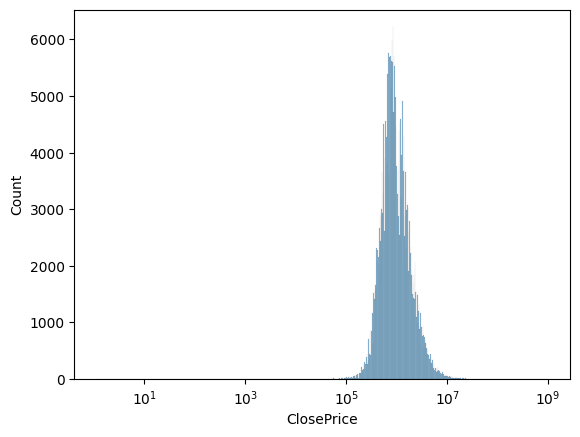

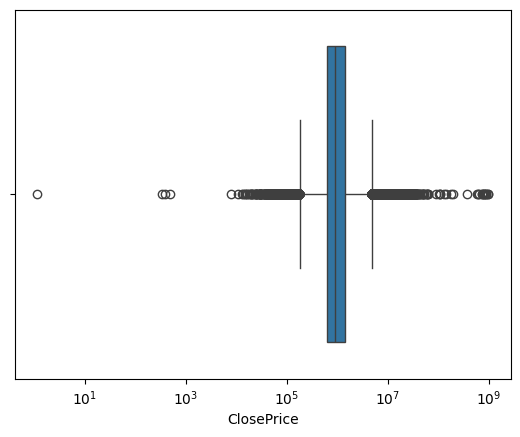

Distribution for LivingArea: 
count    302175.000000
mean       2033.158750
std        1058.132268
min           0.000000
25%        1376.000000
50%        1803.000000
75%        2420.000000
max      123764.000000
Name: LivingArea, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


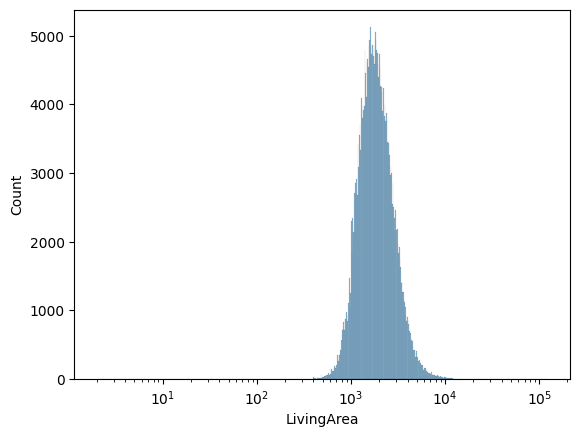

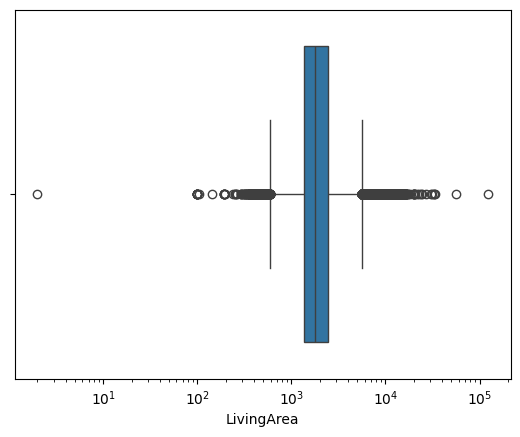

Distribution for BedroomsTotal: 
count    302332.000000
mean          3.480095
std           0.960818
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


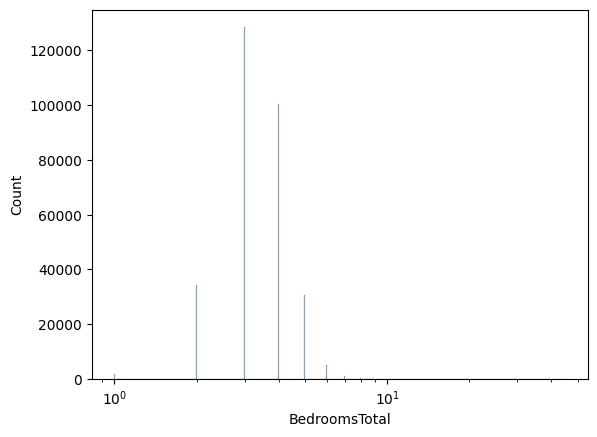

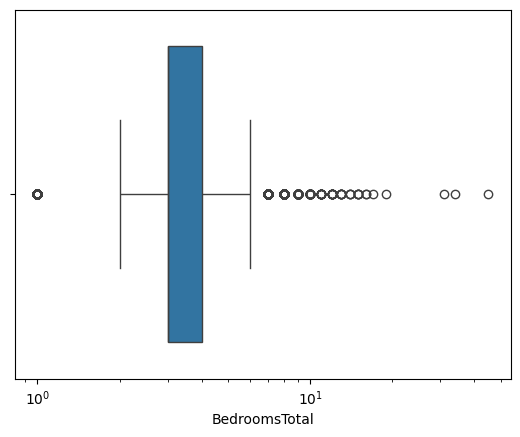

Distribution for BathroomsTotalInteger: 
count    302282.000000
mean          2.615687
std           1.200767
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


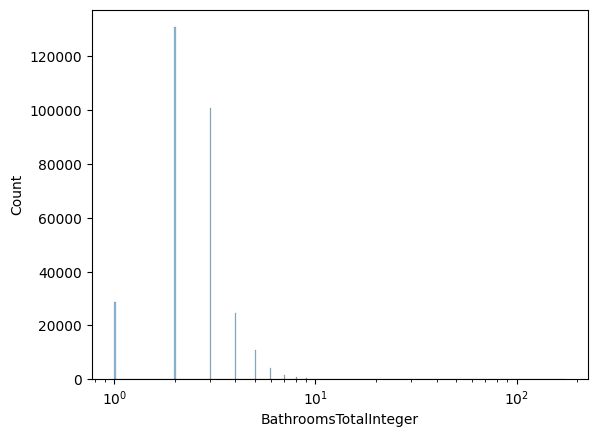

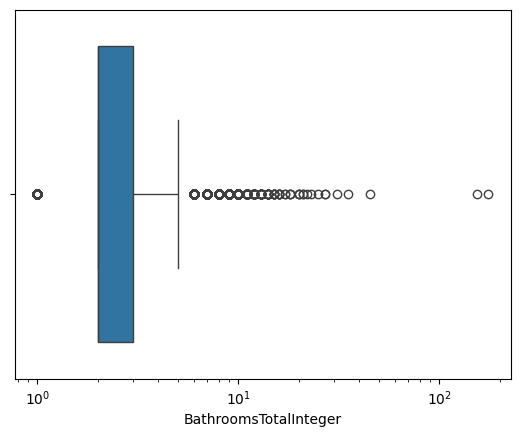

Distribution for LotSizeArea: 
count    2.971680e+05
mean     2.090877e+04
std      7.122236e+05
min      0.000000e+00
25%      5.470000e+03
50%      7.100000e+03
75%      9.904000e+03
max      2.178000e+08
Name: LotSizeArea, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


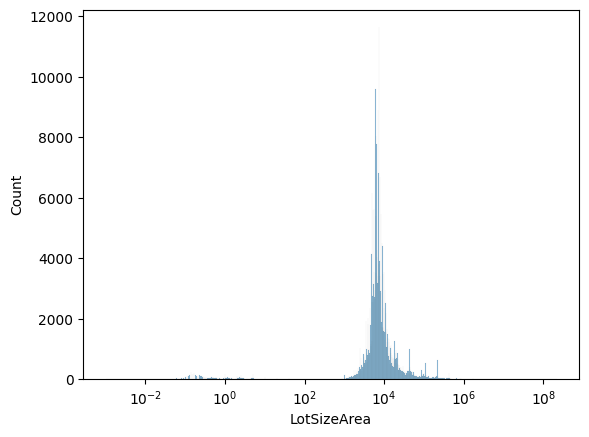

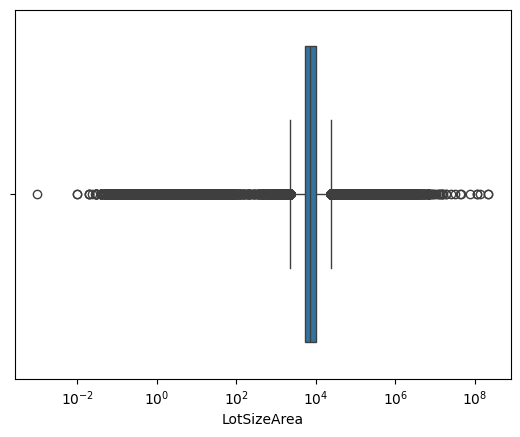

In [10]:
cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeArea']
for col in cols:
    print(f"Distribution for {col}: ")
    print(df[col].describe())

    # Since dataset is so large, log_scale the values to better see the distribution and avoid single bins
    sns.histplot(df[col], kde=True, log_scale=True)
    plt.show()

    sns.boxplot(x=df[col], log_scale=True)
    plt.show()

### Final Data Exploration Summary:

- After combining the monthly sold files and filtering the data, there are 302,332 rows of data that are Single Family Residences
- 84 columns/variable types
- There seems to be at least 1 null value in every row of data (lots of column mismatches between the data but should be fine for now)
- Avg `ClosePrice` is about $1,295,772
- Avg `LivingArea` is about 2,033 sq ft
- Avg number of Bedrooms is about 3 and Bathrooms is 2

